<a href="https://colab.research.google.com/github/NishaSharma077/System-Capacity-Care-Load-Analytics-Dashboard/blob/main/HHS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **System Capacity & Care Load Analytics for Unaccompanied Children**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('//content/drive/MyDrive/HHS_Unaccompanied_Alien_Children_Program.csv')

df.head()

Mounted at /content/drive


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [3]:
df.shape

(1170, 6)

In [4]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

In [5]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


# **Data Cleaning**

In [6]:
df.isnull().sum()
df = df.dropna(how="all")
df.isnull().sum()
df.shape

(720, 6)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()
print(df["Date"].min())
print(df["Date"].max())

2023-01-12 00:00:00
2025-12-21 00:00:00


In [9]:
duplicated = df["Date"].duplicated().sum()
print(duplicated)

df.loc[df["Date"].duplicated(), "Date"].nunique()

0


0

Total System Load

In [10]:

# Remove commas and convert to number
df["Children in HHS Care"] = ( df["Children in HHS Care"] .astype(str) .str.replace(",", "") .astype(float) )

# Count duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Count duplicate dates
print("Duplicate dates:", df["Date"].duplicated().sum())

Duplicate rows: 0
Duplicate dates: 0


In [11]:
#select numeric columns

numeric_columns = [ "Children apprehended and placed in CBP custody*",
                   "Children in CBP custody",
                    "Children transferred out of CBP custody",
                    "Children in HHS Care",
                    "Children discharged from HHS Care" ]

print((df[numeric_columns]<0).sum())

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


In [12]:
# Find rows where transfers are greater than CBP custody
problem_rows = df[ df["Children transferred out of CBP custody"] > df["Children in CBP custody"] ]
print(problem_rows)
print("Problem rows:", len(problem_rows))

          Date  Children apprehended and placed in CBP custody*  \
716 2023-01-24                                             47.0   
715 2023-01-25                                             20.0   
710 2023-02-02                                             15.0   
697 2023-02-22                                            107.0   
696 2023-02-23                                            101.0   
..         ...                                              ...   
217 2025-01-30                                             47.0   
216 2025-02-02                                             20.0   
211 2025-02-09                                             15.0   
207 2025-02-13                                             15.0   
198 2025-02-27                                             10.0   

     Children in CBP custody  Children transferred out of CBP custody  \
716                     42.0                                     47.0   
715                     22.0                     

In [13]:
# Find rows where discharges are greater than HHS care
problem_rows_2 = df[ df["Children discharged from HHS Care"] > df["Children in HHS Care"] ]
print("Problem rows:", len(problem_rows_2))

Problem rows: 0


In [14]:
# Create complete date range
all_dates = pd.date_range( start=df["Date"].min(), end=df["Date"].max(), freq="D" )
 # Find missing dates
missing_dates = all_dates[ ~all_dates.isin(df["Date"]) ]
print("Missing dates:", len(missing_dates))
print(missing_dates)

Missing dates: 355
DatetimeIndex(['2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-26',
               ...
               '2025-11-22', '2025-11-26', '2025-11-28', '2025-11-29',
               '2025-12-05', '2025-12-06', '2025-12-12', '2025-12-13',
               '2025-12-19', '2025-12-20'],
              dtype='datetime64[ns]', length=355, freq=None)


In [15]:
# Save the cleaned data
df.to_csv( "UAC_cleaned_dataset.csv", index=False )
print("Cleaning completed successfully!")

# Display final dataset information
print(df.info())
df.head()

Cleaning completed successfully!
<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 719 to 0
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    float64       
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 39.4 KB
None


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
719,2023-01-12,33.0,53.0,34.0,6566.0,436.0
718,2023-01-22,32.0,49.0,39.0,7122.0,227.0
717,2023-01-23,32.0,50.0,39.0,7280.0,181.0
716,2023-01-24,47.0,42.0,47.0,7433.0,175.0
715,2023-01-25,20.0,22.0,41.0,7538.0,180.0


# **KPI Calculation**

In [16]:
# Total system load

df["Total System Load"] = df["Children in CBP custody"] + df["Children in HHS Care"]
# View the result

df[ [ "Date", "Children in CBP custody", "Children in HHS Care", "Total System Load" ] ].head()

,Date,Children in CBP custody,Children in HHS Care,Total System Load
719,2023-01-12,53.0,6566.0,6619.0
718,2023-01-22,49.0,7122.0,7171.0
717,2023-01-23,50.0,7280.0,7330.0
716,2023-01-24,42.0,7433.0,7475.0
715,2023-01-25,22.0,7538.0,7560.0


In [17]:
#Net intake Pressure

df["Net intake Pressure"] =  df["Children transferred out of CBP custody"] - df["Children discharged from HHS Care"]
#view the result
df[  ["Date", "Children transferred out of CBP custody", "Children discharged from HHS Care", "Net intake Pressure"]].head()

,Date,Children transferred out of CBP custody,Children discharged from HHS Care,Net intake Pressure
719,2023-01-12,34.0,436.0,-402.0
718,2023-01-22,39.0,227.0,-188.0
717,2023-01-23,39.0,181.0,-142.0
716,2023-01-24,47.0,175.0,-128.0
715,2023-01-25,41.0,180.0,-139.0


In [18]:
#Care Load Growth Rate

df["Care Load Growth Rate"] = (df["Total System Load"].pct_change()*100)
df[ [ "Date", "Total System Load", "Care Load Growth Rate" ] ].head()

,Date,Total System Load,Care Load Growth Rate
719,2023-01-12,6619.0,NaN
718,2023-01-22,7171.0,8.339628
717,2023-01-23,7330.0,2.217264
716,2023-01-24,7475.0,1.978172
715,2023-01-25,7560.0,1.137124


In [19]:
#7 day rolling average

df["7 Day Rolling Average"] = ( df["Total System Load"] .rolling(window=7) .mean() )
df[ [ "Date", "Total System Load", "7 Day Rolling Average" ] ].head()

,Date,Total System Load,7 Day Rolling Average
719,2023-01-12,6619.0,NaN
718,2023-01-22,7171.0,NaN
717,2023-01-23,7330.0,NaN
716,2023-01-24,7475.0,NaN
715,2023-01-25,7560.0,NaN


In [20]:
# 14 Day Rolling Average

df["14 Day Rolling Average"] = ( df["Total System Load"] .rolling(window=14).mean())
df[ [ "Date", "Total System Load", "14 Day Rolling Average" ] ].head()

,Date,Total System Load,14 Day Rolling Average
719,2023-01-12,6619.0,NaN
718,2023-01-22,7171.0,NaN
717,2023-01-23,7330.0,NaN
716,2023-01-24,7475.0,NaN
715,2023-01-25,7560.0,NaN


In [21]:
#create backlog indicator

df["Backlog Indicator"] = np.where( df["Net intake Pressure"] > 0, 1, 0 )
 # View results
df[ [ "Date", "Net intake Pressure", "Backlog Indicator" ] ].head()


,Date,Net intake Pressure,Backlog Indicator
719,2023-01-12,-402.0,0
718,2023-01-22,-188.0,0
717,2023-01-23,-142.0,0
716,2023-01-24,-128.0,0
715,2023-01-25,-139.0,0


In [22]:
#cumulative Backlog

df["Cumulative Backlog"] = df["Net intake Pressure"].cumsum()
df[ [ "Date", "Net intake Pressure", "Cumulative Backlog" ]].head()

,Date,Net intake Pressure,Cumulative Backlog
719,2023-01-12,-402.0,-402.0
718,2023-01-22,-188.0,-590.0
717,2023-01-23,-142.0,-732.0
716,2023-01-24,-128.0,-860.0
715,2023-01-25,-139.0,-999.0


In [23]:
# Care Load Volatility, Calculate daily change

df["Daily Load Change"] = df["Total System Load"].diff()
# Calculate rolling volatility over 7 observations
df["Care Load Volatility Index"] = ( df["Daily Load Change"] .rolling(window=7) .std() )

# View results
df[ [ "Date", "Total System Load", "Care Load Volatility Index" ] ].head(15)


,Date,Total System Load,Care Load Volatility Index
719,2023-01-12,6619.0,NaN
718,2023-01-22,7171.0,NaN
717,2023-01-23,7330.0,NaN
716,2023-01-24,7475.0,NaN
715,2023-01-25,7560.0,NaN
714,2023-01-29,7517.0,NaN
713,2023-01-30,7797.0,NaN
712,2023-01-31,7839.0,194.773128
711,2023-02-01,7935.0,101.139225
710,2023-02-02,7892.0,112.699770


In [24]:
# Backlog Accumulation Rate
df["Backlog Accumulation Rate"] = np.where( df["Total System Load"] > 0, ( df["Net intake Pressure"] / df["Total System Load"] ) * 100, 0 )
# View results
df[ [ "Date", "Net intake Pressure", "Total System Load", "Backlog Accumulation Rate" ] ].head()

,Date,Net intake Pressure,Total System Load,Backlog Accumulation Rate
719,2023-01-12,-402.0,6619.0,-6.073425
718,2023-01-22,-188.0,7171.0,-2.621671
717,2023-01-23,-142.0,7330.0,-1.937244
716,2023-01-24,-128.0,7475.0,-1.712375
715,2023-01-25,-139.0,7560.0,-1.838624


In [25]:
# Discharge Offset Ratio
df["Discharge Offset Ratio"] = np.where( df["Children transferred out of CBP custody"] > 0,
 ( df["Children discharged from HHS Care"] / df["Children transferred out of CBP custody"] ) * 100, 0 )

# View results
df[ [ "Date",
     "Children transferred out of CBP custody",
      "Children discharged from HHS Care",
      "Discharge Offset Ratio" ] ].head()

,Date,Children transferred out of CBP custody,Children discharged from HHS Care,Discharge Offset Ratio
719,2023-01-12,34.0,436.0,1282.352941
718,2023-01-22,39.0,227.0,582.051282
717,2023-01-23,39.0,181.0,464.102564
716,2023-01-24,47.0,175.0,372.340426
715,2023-01-25,41.0,180.0,439.024390


In [26]:
#create KPI summary

kpi_summary = {
    "Average Total System Load":
    df["Total System Load"].mean(),
    "Maximum Total System Load":
    df["Total System Load"].max(),
    "Minimum Total System Load":
    df["Total System Load"].min(),
    "Average Net intake Pressure":
    df["Net intake Pressure"].mean(),
    "Total Net intake Pressure":
    df["Net intake Pressure"].sum(),
    "Average Care Load Growth Rate":
    df["Care Load Growth Rate"].mean(),
    "Average Backlog Accumulation Rate":
    df["Backlog Accumulation Rate"].mean(),
    "Average Discharge Offset Ratio":
    df["Discharge Offset Ratio"].mean(),
    "Average Care Load Volatility":
    df["Care Load Volatility Index"].mean(),

    }
    # Display KPI results
for kpi, value in kpi_summary.items():
  print(kpi, ":", round(value, 2))

Average Total System Load : 6232.77
Maximum Total System Load : 11762.0
Minimum Total System Load : 2002.0
Average Net intake Pressure : -44.74
Total Net intake Pressure : -32212.0
Average Care Load Growth Rate : -0.12
Average Backlog Accumulation Rate : -0.55
Average Discharge Offset Ratio : 200.51
Average Care Load Volatility : 103.67


In [27]:
# Count days with positive intake pressure
high_pressure_days = ( df["Net intake Pressure"] > 0 ).sum()
print( "Days with positive intake pressure:", high_pressure_days )

Days with positive intake pressure: 238


In [28]:
#find the day with the highest total system load

max_load_rows = df.loc[
    df["Total System Load"].idxmax(),

]
print("Date:" ,max_load_rows["Date"])
print(
    "Highest Total System Load:",
    max_load_rows["Total System Load"]
)

Date: 2023-12-20 00:00:00
Highest Total System Load: 11762.0


In [29]:
# find the day with the lowest system load

min_load_rows = df.loc[
    df["Total System Load"].idxmin(),

]
print("Date:" ,min_load_rows["Date"])
print(
    "Lowest Total System Load:",
    min_load_rows["Total System Load"])

Date: 2025-08-24 00:00:00
Lowest Total System Load: 2002.0


In [30]:
#Save the dataset with all new KPI columns

df.to_csv("UAC_KPI_Analysis_Dataset.csv",
          index=False )
print("File saved as: UAC_KPI_Analysis_Dataset.csv")
df.head()

File saved as: UAC_KPI_Analysis_Dataset.csv


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Total System Load,Net intake Pressure,Care Load Growth Rate,7 Day Rolling Average,14 Day Rolling Average,Backlog Indicator,Cumulative Backlog,Daily Load Change,Care Load Volatility Index,Backlog Accumulation Rate,Discharge Offset Ratio
719,2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,-402.0,NaN,NaN,NaN,0,-402.0,NaN,NaN,-6.073425,1282.352941
718,2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,-188.0,8.339628,NaN,NaN,0,-590.0,552.0,NaN,-2.621671,582.051282
717,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,-142.0,2.217264,NaN,NaN,0,-732.0,159.0,NaN,-1.937244,464.102564
716,2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,-128.0,1.978172,NaN,NaN,0,-860.0,145.0,NaN,-1.712375,372.340426
715,2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,-139.0,1.137124,NaN,NaN,0,-999.0,85.0,NaN,-1.838624,439.024390


Exploratory Data Analysis

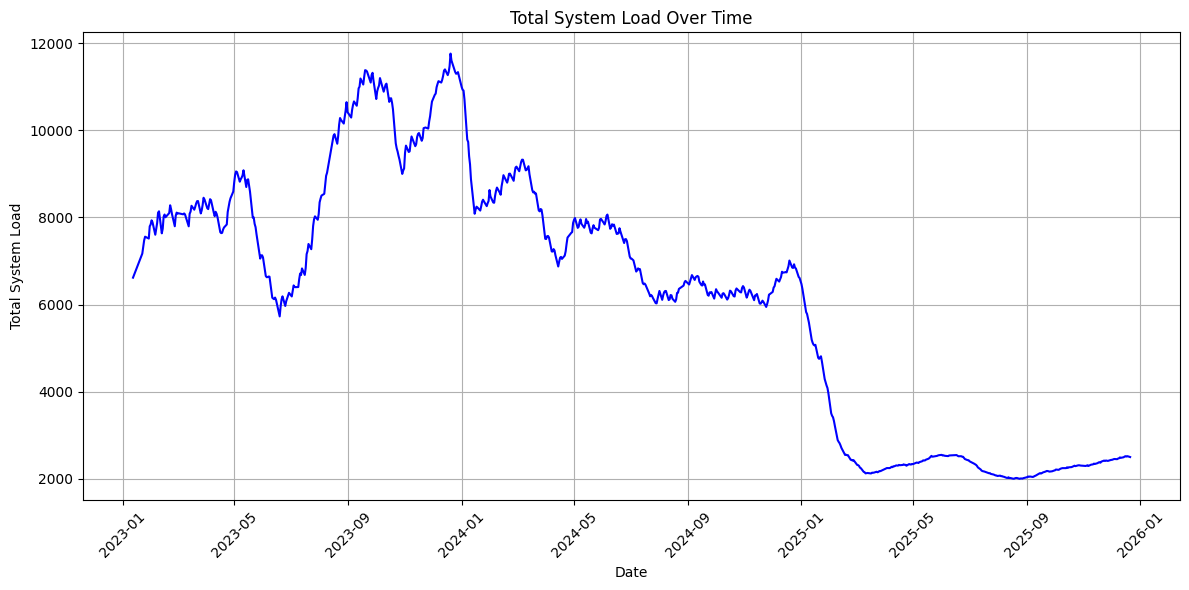

In [31]:
#Total System Load Over Time

plt.figure(figsize=(12,6))
plt.plot(
    df["Date"],
    df["Total System Load"],
    color="blue",
)
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.title("Total System Load Over Time")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



*   The total system load peaked during late 2023 and early 2024.<BR>
*   A significant decline occurred in early 2025.<BR>


*  The system remained relatively stable after the decline.






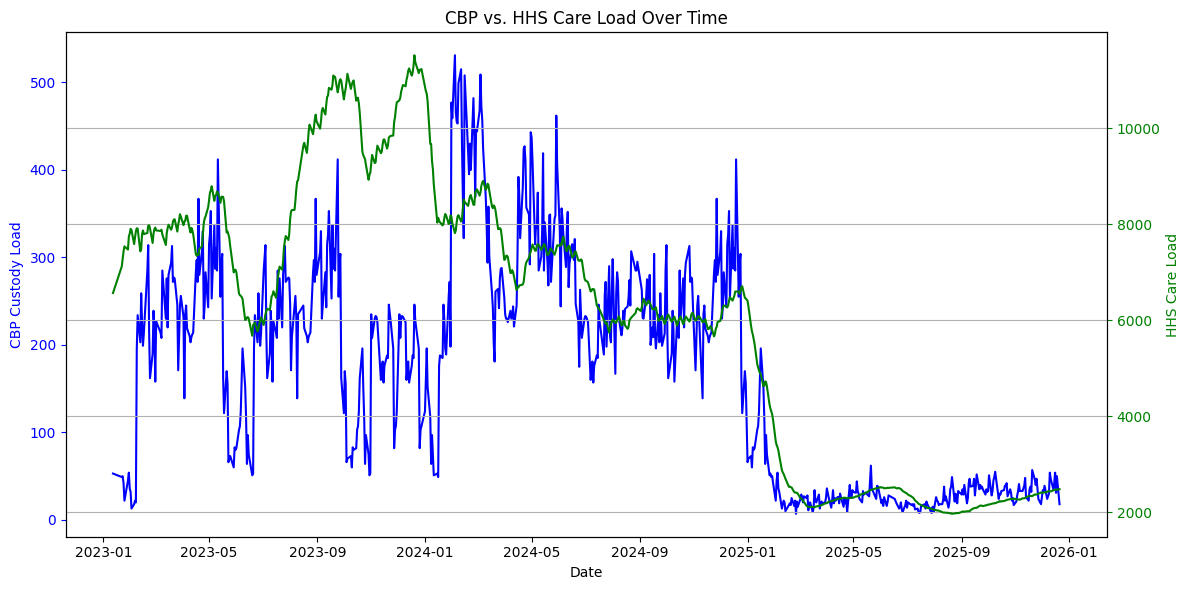

In [32]:
#CBP VS HHS Care Load

fig, ax1 = plt.subplots(figsize=(12,6))

# Plot CBP custody load
ax1.plot(df["Date"], df["Children in CBP custody"], label = "CBP Custody", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("CBP Custody Load", color="blue")
ax1.tick_params("y", colors="blue")

 #Plot HHS custody load

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Children in HHS Care"], label = "HHS Care", color="green")
ax2.set_ylabel("HHS Care Load", color="green")
ax2.tick_params("y", colors="green")
plt.title("CBP vs. HHS Care Load Over Time")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



*   HHS consistently cared for more children than CBP.



*  HHS handled the majority of the care burden.


*  CBP custody remained comparatively low throughout the period.



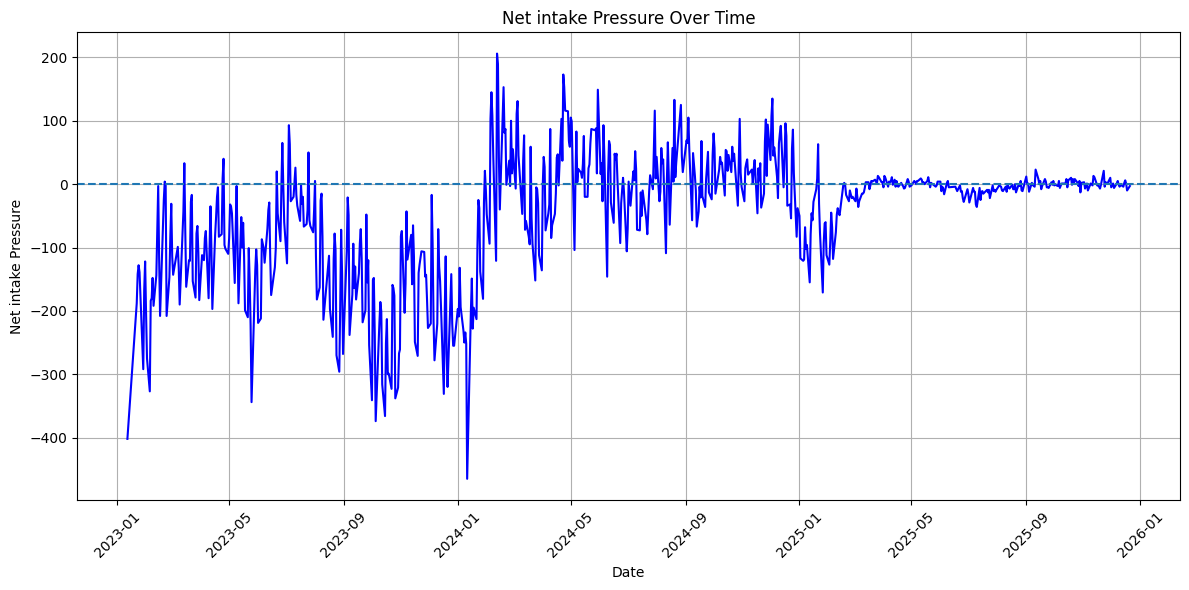

In [33]:
# Net intake Pressure

plt.figure(figsize=(12,6))
plt.plot(
    df["Date"],
    df["Net intake Pressure"],
    color="blue",
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Date")
plt.ylabel("Net intake Pressure")
plt.title("Net intake Pressure Over Time")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Positive net intake indicates more children entered the system than were discharged.<BR>
Negative net intake indicates the system was reducing its care load.

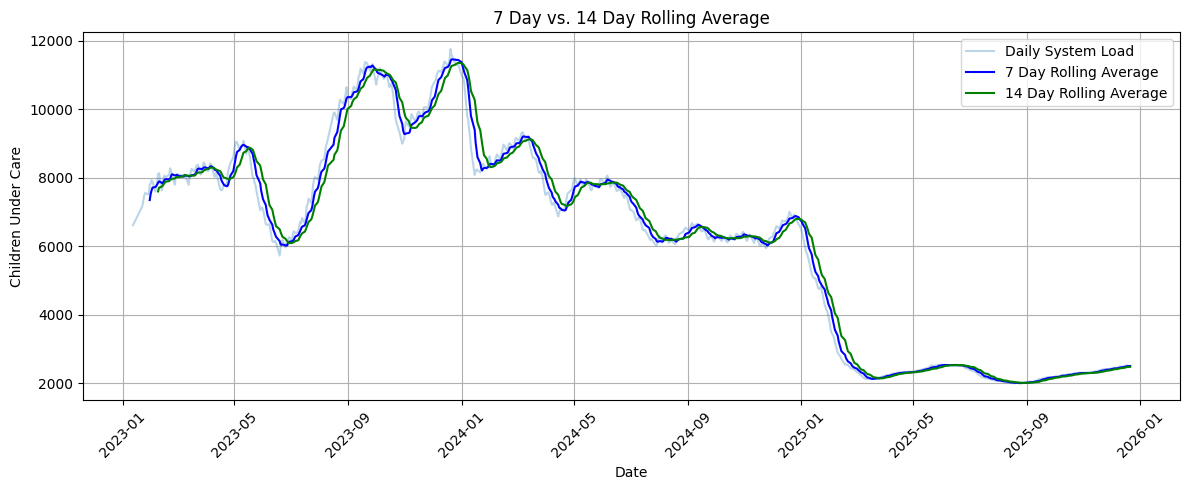

In [34]:
# 7 day vs 14 day rolling average

plt.figure(figsize=(12,5))
plt.plot(
    df["Date"],
    df["Total System Load"],
    alpha=0.3,
    label="Daily System Load"
)
plt.plot(df["Date"], df["7 Day Rolling Average"], label="7 Day Rolling Average", color="blue")
plt.plot(df["Date"], df["14 Day Rolling Average"], label="14 Day Rolling Average", color="green")
plt.xlabel("Date")
plt.ylabel("Children Under Care")
plt.title("7 Day vs. 14 Day Rolling Average")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The 7-day and 14-day averages smooth daily fluctuations.<BR>
Both averages show sustained increases and decreases rather than isolated daily spikes.

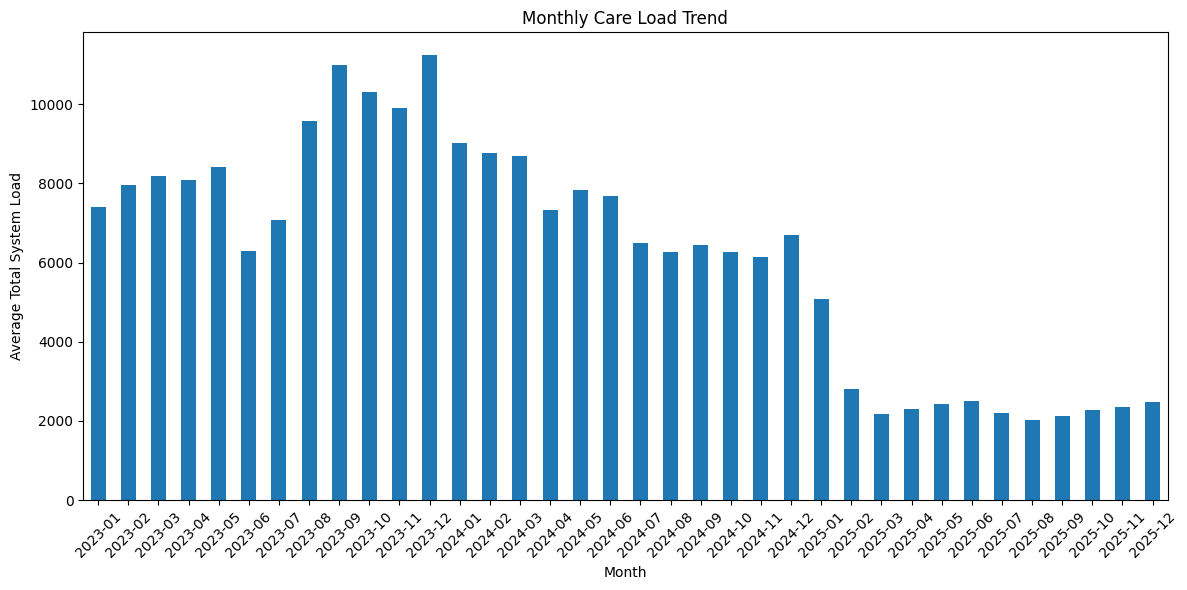

In [35]:
#Monthly Care Load Trend
df["Month"]= df["Date"].dt.to_period("M")

Monthly_Load = df.groupby("Month")["Total System Load"].mean()
plt.figure(figsize=(12,6))
Monthly_Load.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Average Total System Load")
plt.title("Monthly Care Load Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

          Date  Total System Load
495 2023-12-20            11762.0
494 2023-12-21            11603.0
496 2023-12-19            11476.0
499 2023-12-14            11399.0
558 2023-09-19            11382.0
557 2023-09-20            11374.0
500 2023-12-13            11373.0
556 2023-09-21            11352.0
493 2023-12-25            11340.0
497 2023-12-18            11337.0


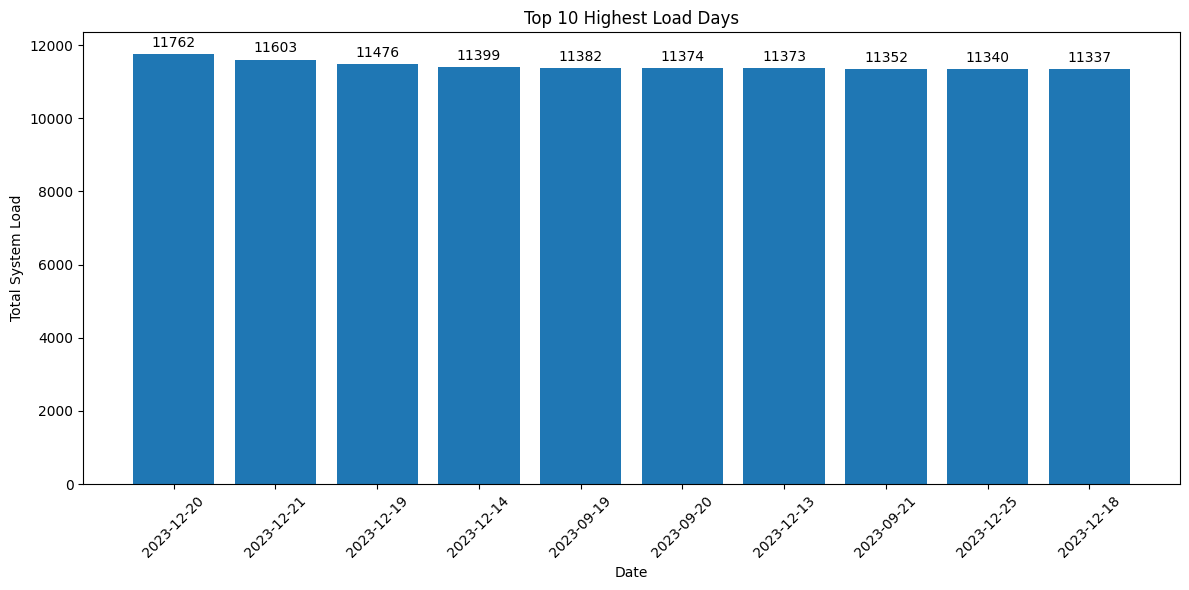

In [36]:
#highest load period

Top_Load_Days = (
    df[
        [
            "Date",
            "Total System Load"
        ]
    ]
    .dropna().sort_values("Total System Load", ascending=False)
    .head(10)
)
print(Top_Load_Days)

plt.figure(figsize=(12,6))
bars = plt.bar(
    Top_Load_Days["Date"].astype(str),

    Top_Load_Days["Total System Load"],

)
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.title("Top 10 Highest Load Days")
plt.xticks(rotation=45)
plt.tight_layout()
# Add data labels
plt.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)
plt.show()
#


In [37]:
#Identify Sustained Positive Intake

Valid_Pressure = df["Net intake Pressure"].dropna()

Positive_Percentage = (Valid_Pressure > 0).mean() * 100
print(f"Percentage of days with positive intake pressure: {Positive_Percentage:.2f}%")

Percentage of days with positive intake pressure: 33.06%


In [38]:
#Summary Table

summary = pd.DataFrame({
    "Metric": [
        "Average Total System Load",
        "Maximum Total System Load",
        "Minimum Total System Load",
        "Average Net Intake Pressure",
        "Maximum Net Intake Pressure",
        "Minimum Net Intake Pressure",
        "Positive Intake Days (%)"
    ],
    "Value": [
        df["Total System Load"].mean(),
        df["Total System Load"].max(),
        df["Total System Load"].min(),
        df["Net intake Pressure"].mean(),
        df["Net intake Pressure"].max(),
        df["Net intake Pressure"].min(),
        Positive_Percentage
    ]
})

summary

,Metric,Value
0,Average Total System Load,6232.769444
1,Maximum Total System Load,11762.000000
2,Minimum Total System Load,2002.000000
3,Average Net Intake Pressure,-44.738889
4,Maximum Net Intake Pressure,206.000000
5,Minimum Net Intake Pressure,-465.000000
6,Positive Intake Days (%),33.055556


# **Streamlit Dashboard**

2026-07-29 05:44:04.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:04.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:04.561 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:04.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:04.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:04.564 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:04.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:04.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

datetime64[ns]


2026-07-29 05:44:05.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:05.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:05.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:05.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:05.656 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:05.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:05.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 05:44:05.659 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

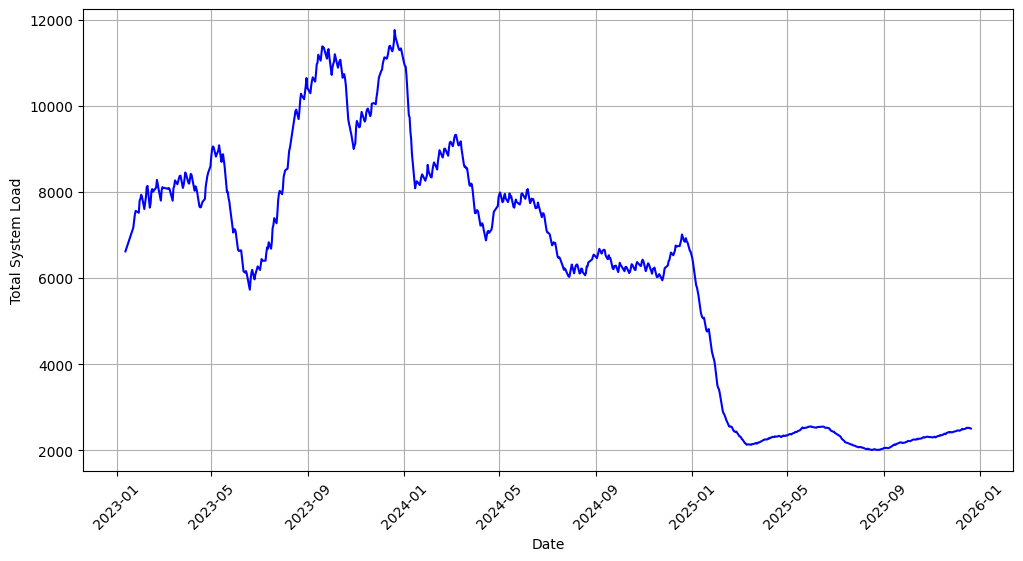

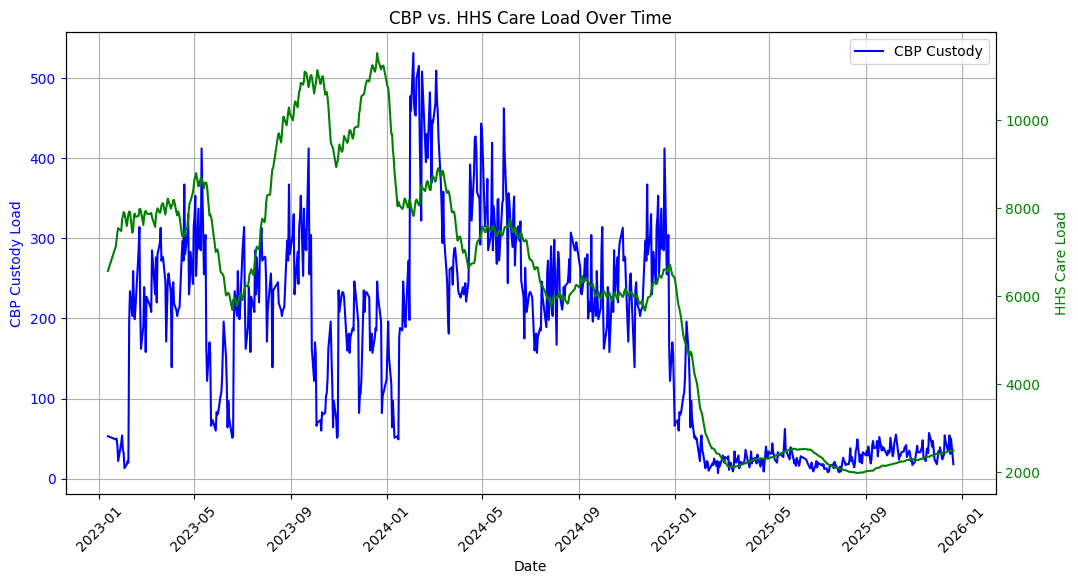

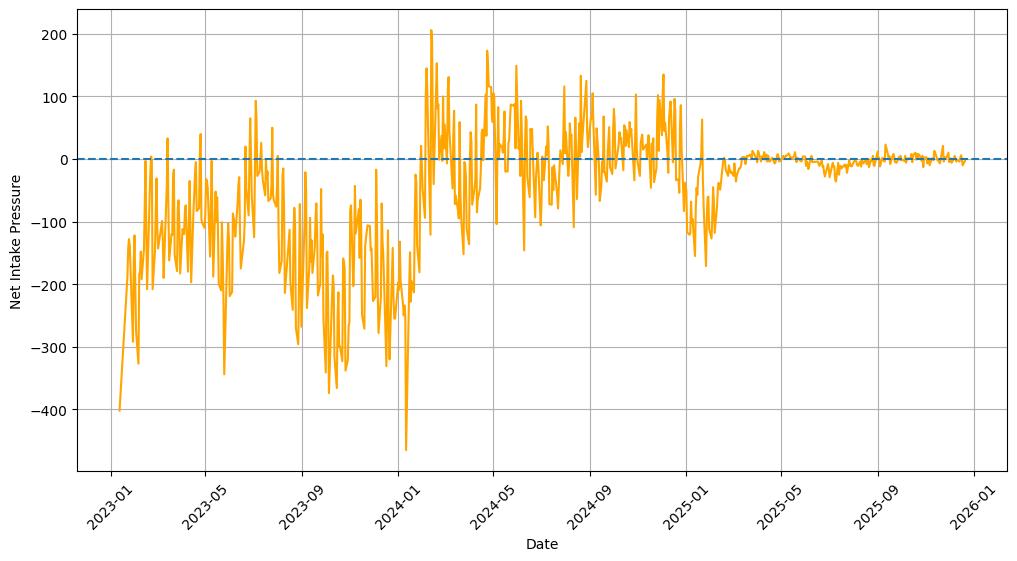

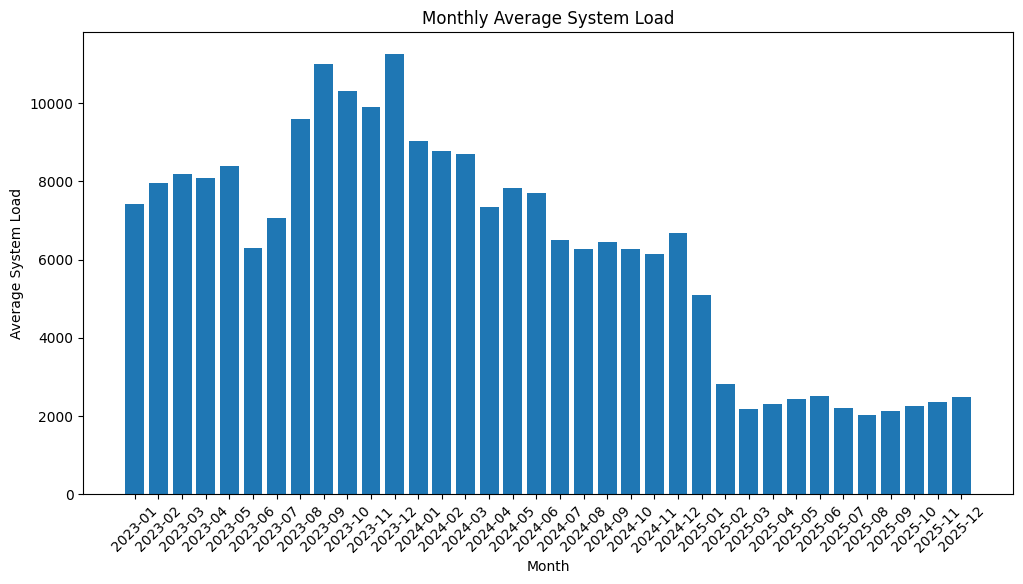

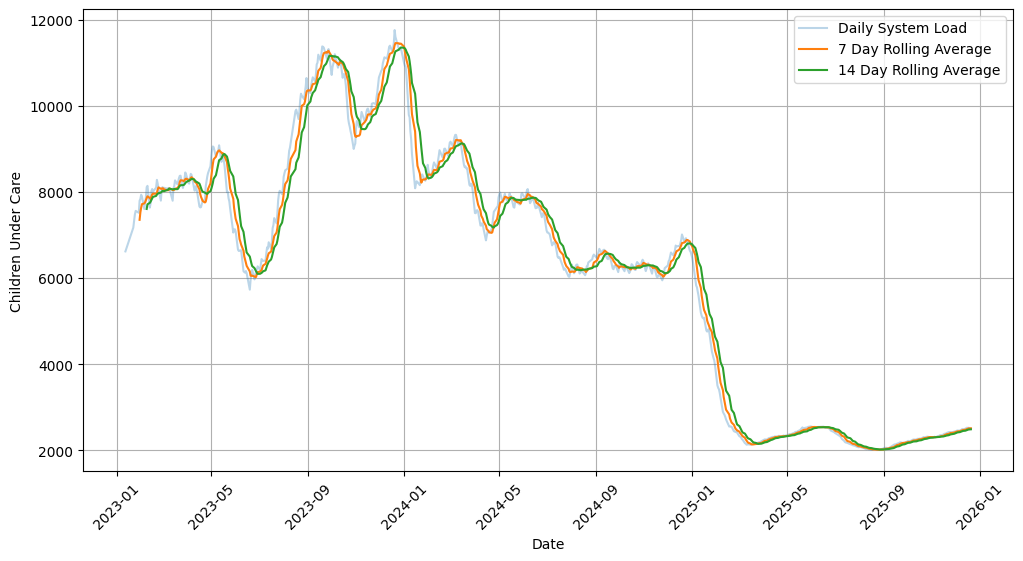

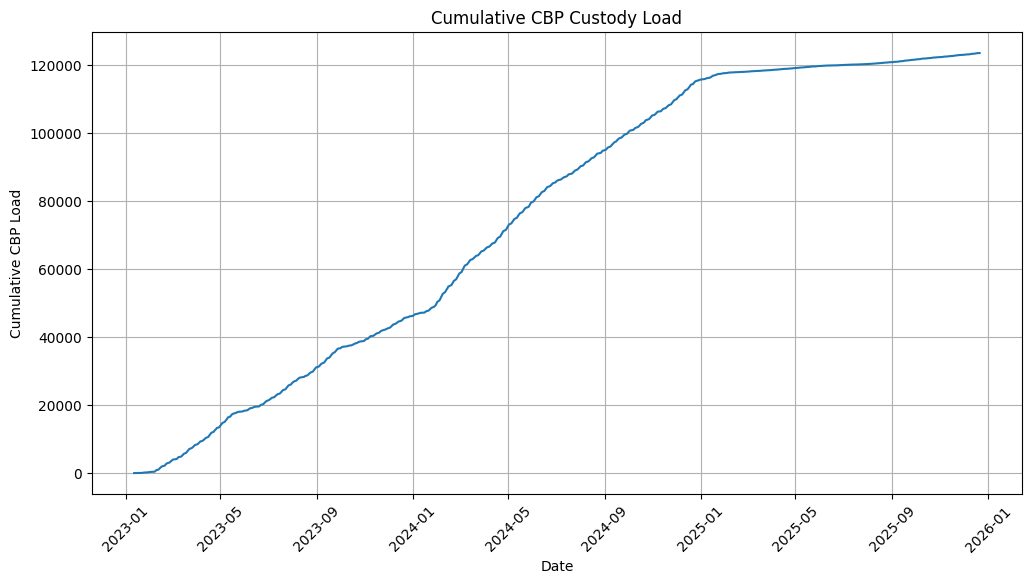

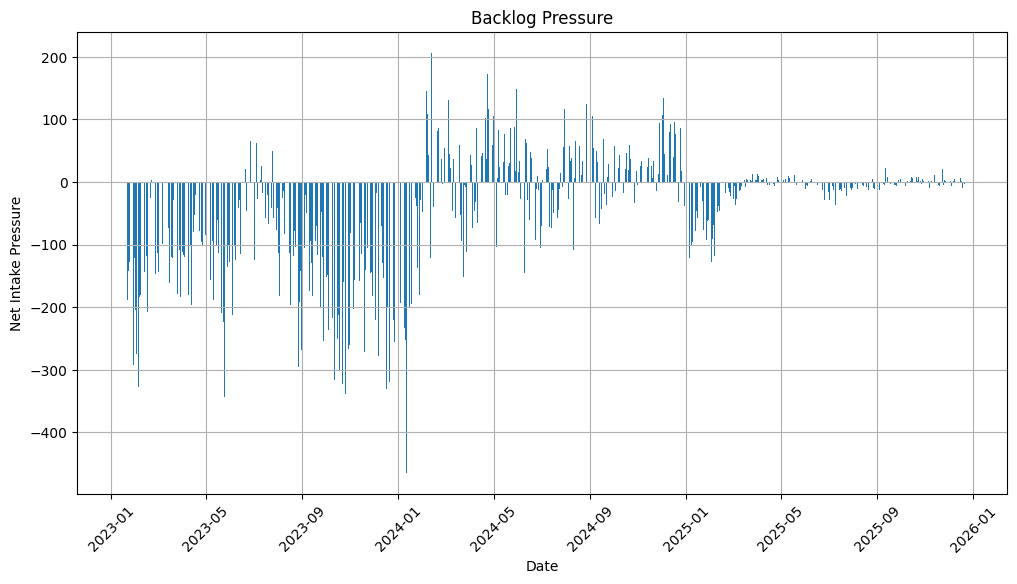

In [4]:
!pip install --upgrade streamlit
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="System Capacity Dashboard",
    page_icon="🏥",
    layout="wide",
)
# ============================================================
# CUSTOM DASHBOARD STYLING
# ============================================================

st.markdown("""
<style>

    /* Main title */
    .main-title {
        font-size: 38px;
        font-weight: bold;
        text-align: center;
        padding: 20px;
    }

    /* Subtitle */
    .subtitle {
        text-align: center;
        font-size: 18px;
        margin-bottom: 30px;
    }

    /* KPI Cards */
    .kpi-card {
        padding: 20px;
        border-radius: 12px;
        text-align: center;
        border: 1px solid #ddd;
        background-color: #f8f9fa;
    }

    .kpi-title {
        font-size: 16px;
        font-weight: bold;
    }

    .kpi-value {
        font-size: 28px;
        font-weight: bold;
    }

    /* Sidebar */
    section[data-testid="stSidebar"] {
        padding-top: 20px;
    }

    /* Buttons */
    .stButton > button {
        width: 100%;
        border-radius: 8px;
        font-weight: bold;
        padding: 10px;

/* Tab container */
.stTabs [data-baseweb="tab-list"] {
    gap: 20px !important;
    background-color: #f0f2f6 !important;
    padding: 30px !important;
    border-radius: 20px !important;
}

.stTabs [data-baseweb="tab"] {
    background-color: white !important;
    border-radius: 30px !important;
    padding: 30px 0px !important;
    font-weight: 700 !important;
    font-size: 18px !important;
}

.stTabs [data-baseweb="tab"]:hover {
    background-color: #e3f2fd !important;
}

.stTabs [aria-selected="true"] {
    background-color: #2196f3 !important;
    color: white !important;
}

  /* Download button */
.stDownloadButton > button {
        width: 100%;
        border-radius: 8px;
        font-weight: bold;
        padding: 12px;
    }

</style>
""", unsafe_allow_html=True)

st.markdown(
    '<div class="main-title">🏥 System Capacity & Care Load Analytics Dashboard</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'Monitoring care load, intake pressure, and system capacity '
    'for Unaccompanied Children'
    '</div>',
    unsafe_allow_html=True
)

#load dataset
df = pd.read_csv("//content/drive/MyDrive/HHS_Unaccompanied_Alien_Children_Program.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()


# ============================================================
# CONVERT DATE
# ============================================================

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)


# ============================================================
# CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )
st.subheader("🔍 Data Quality Checks")

missing_dates = df["Date"].isna().sum()

duplicate_dates = df["Date"].duplicated().sum()

invalid_transfers = (
    df[
        df["Children transferred out of CBP custody"]
        >
        df["Children in CBP custody"]
    ]
).shape[0]

st.write(
    f"Missing dates: {missing_dates}"
)

st.write(
    f"Duplicate dates: {duplicate_dates}"
)

st.write(
    f"Potential transfer anomalies: {invalid_transfers}"
)
#Create Metrics


df["Total System Load"] = (
    df["Children in CBP custody"].fillna(0) +
    df["Children in HHS Care"].fillna(0)
)
df["Net intake Pressure"] = (
    df["Children transferred out of CBP custody"].fillna(0) -
    df["Children discharged from HHS Care"].fillna(0)
)
# Cumulative System Load
df = df.sort_values("Date").reset_index(drop=True)
df["Cumulative System Load"] = (
    df["Total System Load"].cumsum()
)


df["7 Day Rolling Average"] = (df["Total System Load"].rolling(window=7).mean())
df["14 Day Rolling Average"] = (df["Total System Load"].rolling(window=14).mean())

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].dtype)
df = df.dropna(subset=["Date"])
#Sidebar Filter

start_date = st.sidebar.date_input(
    "Start Date",
    value=df["Date"].min().date()
)

end_date = st.sidebar.date_input(
    "End Date",
    value=df["Date"].max().date()
)

filtered = df[
    (df["Date"] >= pd.to_datetime(start_date)) &

    (df["Date"] <= pd.to_datetime(end_date))
]

# ============================================================
# BACKLOG ANALYSIS
# ============================================================

filtered["Backlog Indicator"] = (
    filtered["Net intake Pressure"] > 0
)

backlog_days = (
    filtered["Backlog Indicator"].sum()
)


# ============================================================
# VOLATILITY ANALYSIS
# ============================================================

if filtered["Total System Load"].mean() != 0:

    volatility_index = (
        filtered["Total System Load"].std()
        / filtered["Total System Load"].mean()
    ) * 100

else:

    volatility_index = 0


# ============================================================
# CAPACITY STRESS ANALYSIS
# ============================================================

stress_threshold = filtered[
    "Total System Load"
].quantile(0.90)

stress_periods = filtered[
    filtered["Total System Load"] >= stress_threshold
]


#Discharge offset ratio


total_transfers = filtered[
    "Children transferred out of CBP custody"
].sum()

total_discharges = filtered[
    "Children discharged from HHS Care"
].sum()

if total_transfers > 0:

    discharge_offset_ratio = (
        total_discharges / total_transfers
    ) * 100

else:

    discharge_offset_ratio = 0

# Month filter
months = sorted(
    df["Date"].dt.month_name().dropna().unique()
)

selected_month = st.sidebar.selectbox(
    "Select Month",
    ["All Months"] + months
)

# Year filter
years = sorted(
    df["Date"].dt.year.dropna().unique()
)

selected_year = st.sidebar.selectbox(
    "Select Year",
    ["All Years"] + years
)

# 5. FILTER DATA

filtered = df[
    (df["Date"] >= pd.Timestamp(start_date)) &
    (df["Date"] <= pd.Timestamp(end_date))
].copy()
# Backlog Indicator
filtered["Backlog Indicator"] = (
    filtered["Net intake Pressure"] > 0
)

# Count number of backlog pressure days
backlog_days = filtered["Backlog Indicator"].sum()

#Discharge offset ratio
total_transfers = filtered[
    "Children transferred out of CBP custody"
].sum()

total_discharges = filtered[
    "Children discharged from HHS Care"
].sum()

if total_transfers > 0:

    discharge_offset_ratio = (
        total_discharges / total_transfers
    ) * 100

else:

    discharge_offset_ratio = 0

# Month filter
if selected_month != "All Months":
    filtered = filtered[
        filtered["Date"].dt.month_name() == selected_month
    ]


# Year filter
if selected_year != "All Years":
    filtered = filtered[
        filtered["Date"].dt.year == selected_year
    ]
# Care Load Volatility Index
if filtered["Total System Load"].mean() != 0:
    volatility_index = (
        filtered["Total System Load"].std()
        / filtered["Total System Load"].mean()
    ) * 100
else:
    volatility_index = 0

# Check if data exists
if filtered.empty:

    st.warning(
        "No data available for the selected filters."
    )

    st.stop()

#Metric Selection

st.sidebar.subheader("📈 Metric Selector")

metric_option = st.sidebar.selectbox(
    "Select Metric",
    [
        "Total System Load",
        "Net intake Pressure",
        "Children in CBP custody",
        "Children in HHS Care",
    ]
)

metric_columns = {
    "Total System Load": "Total System Load",
    "Net intake Pressure": "Net intake Pressure",
    "Children in CBP custody": "Children in CBP custody",
    "Children in HHS Care": "Children in HHS Care"
}

selected_metric = metric_columns[metric_option]

#KPI Card
#Row 1
col1, col2, col3, col4, col5 = st.columns(5)

with col1:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Total System Load</div>
            <div class="kpi-value">
                {filtered["Total System Load"].sum():,.0f}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col2:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Average Daily Load</div>
            <div class="kpi-value">
                {filtered["Total System Load"].mean():,.0f}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col3:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Peak System Load</div>
            <div class="kpi-value">
                {filtered["Total System Load"].max():,.0f}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col4:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Average Net Intake</div>
            <div class="kpi-value">
                {filtered["Net intake Pressure"].mean():,.0f}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col5:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Highest HHS Care</div>
            <div class="kpi-value">
                {filtered["Children in HHS Care"].max():,.0f}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )
st.markdown("<br>", unsafe_allow_html=True)

# Second Row
col6, col7, col8, col9, col10 = st.columns(5)
with col6:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Care Load Volatility</div>
            <div class="kpi-value">
                {volatility_index:.2f}%
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col7:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Cumulative System Load</div>
            <div class="kpi-value">
                {filtered['Cumulative System Load'].iloc[-1]:,.0f}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col8:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Backlog Pressure Days</div>
            <div class="kpi-value">
                {int(backlog_days)}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col9:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">Discharge Offset Ratio</div>
            <div class="kpi-value">
                {discharge_offset_ratio:.2f}%
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col10:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">High-Pressure Days</div>
            <div class="kpi-value">
                {len(stress_periods)}
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


#Chart of Total System Load

#Chart of Total System Load

st.subheader("Total System Load Over Time")
st.write(
    "This chart shows the total number of children under care over time, "
    "calculated by combining children in CBP custody and children in HHS care. "
    "It helps identify overall changes in system demand and periods of increasing "
    "or decreasing care load."
)
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(
    filtered["Date"],
    filtered["Total System Load"],
    color="blue"
)
ax.set_xlabel("Date")
ax.set_ylabel("Total System Load")
ax.grid(True)
ax.tick_params(axis="x", rotation=45)

st.pyplot(fig)

#CBP vs HHS

st.subheader("CBP vs. HHS Care Load Over Time")
st.write(
    "This chart compares the number of children in CBP custody "
    "with the number of children in HHS care over time. "
    "It helps identify changes in care load and differences between "
    "the two stages of the UAC care system."
)
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(df["Date"], df["Children in CBP custody"], label = "CBP Custody", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("CBP Custody Load", color="blue")
ax1.tick_params("y", colors="blue")

 #Plot HHS custody load

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Children in HHS Care"], label = "HHS Care", color="green")
ax2.set_ylabel("HHS Care Load", color="green")
ax2.tick_params("y", colors="green")
ax1.set_title("CBP vs. HHS Care Load Over Time")
ax1.grid(True)
ax1.legend()
ax1.tick_params(axis="x", rotation=45)

st.pyplot(fig)

#Net Intake Pressrue

st.subheader("Net Intake Pressure Over Time")
st.write(
    "This chart shows the change in net intake pressure over time, "
    "calculated as the number of children transferred out of CBP "
    "custody minus the number of children discharged from HHS care. "
    "Positive values indicate that transfers exceeded discharges, "
    "which may suggest increasing pressure on the care system, "
    "while negative values indicate that discharges exceeded transfers."
)
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(
    filtered["Date"],
    filtered["Net intake Pressure"],
    color="orange"
)
ax.axhline(
    y=0,
    linestyle="--"
)
ax.set_xlabel("Date")
ax.set_ylabel("Net Intake Pressure")
ax.grid(True)
ax.tick_params(axis="x", rotation=45)

st.pyplot(fig)

#Monthly Average Load

filtered["Month"] = filtered["Date"].dt.to_period("M")

Monthly = (filtered.groupby("Month")["Total System Load"].mean())

st.subheader("Monthly Average System Load")
st.write(
    "This chart shows the average system load for each month, "
    "helping to identify monthly trends, seasonal patterns, "
    "and periods of higher or lower care demand."
)
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(Monthly.index.astype(str), Monthly)
ax.set_xlabel("Month")
ax.set_ylabel("Average System Load")
ax.set_title("Monthly Average System Load")
ax.tick_params(axis="x", rotation=45)

st.pyplot(fig)


#7 day vs 14 day rooling average

st.subheader("7 Day vs. 14 Day Rolling Average")
st.write(
    "This chart compares the 7-day and 14-day rolling averages "
    "of the system load to identify short-term and longer-term "
    "trends, smooth daily fluctuations, and highlight periods "
    "of increasing or decreasing care pressure."
)
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    filtered["Date"],
    filtered["Total System Load"],
    alpha=0.3,
    label="Daily System Load"
)

ax.plot(
    filtered["Date"],
    filtered["7 Day Rolling Average"],
    label="7 Day Rolling Average",
)

ax.plot(
    filtered["Date"],
    filtered["14 Day Rolling Average"],
    label="14 Day Rolling Average",
)

ax.set_xlabel("Date")
ax.set_ylabel("Children Under Care")
ax.legend()
ax.grid(True)
ax.tick_params(axis="x", rotation=45)

st.pyplot(fig)



# Calculate cumulative CBP custody load
filtered["Cumulative CBP Load"] = (
    filtered["Children in CBP custody"].cumsum()
)


st.subheader("📊 Cumulative CBP Custody Load")

st.write(
    "This chart shows the cumulative reported CBP "
    "custody load across the selected reporting period."
)

fig,ax = plt.subplots(figsize=(12,6))
ax.plot(
    filtered["Date"],
    filtered["Cumulative CBP Load"]
)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative CBP Load")
ax.set_title("Cumulative CBP Custody Load")
ax.grid(True)
ax.tick_params(axis="x", rotation=45)


st.pyplot(fig)
#Backlog Indicator

st.subheader("📦 Backlog Pressure")
st.write(
        "This section provides an overview of Backlog Pressure "

    )

fig,ax = plt.subplots(figsize=(12,6))
ax.bar(
    filtered["Date"],
    filtered["Net intake Pressure"]
)
ax.set_xlabel("Date")
ax.set_ylabel("Net Intake Pressure")
ax.set_title("Backlog Pressure")
ax.grid(True)
ax.tick_params(axis="x", rotation=45)

st.pyplot(fig)
#download filtered data
st.subheader(
    "📥 Download Filtered Data"
)

csv_data = filtered.to_csv(
    index=False
).encode("utf-8")

st.download_button(
    label="Download CSV",
    data=csv_data,
    file_name="UAC_filtered_analysis.csv",
    mime="text/csv"
)

#insights and recommendation



st.subheader("ℹ️ Key Insights")

peak_load = filtered["Total System Load"].max()

average_load = filtered["Total System Load"].mean()

with st.expander("🔎 View Key Findings"):

    st.write(
        f"The peak total system load was "
        f"{filtered['Total System Load'].max():,.0f} children."
    )

    st.write(
        f"The average daily system load was "
        f"{filtered['Total System Load'].mean():,.0f} children."
    )

    st.write(
        "Positive net intake pressure indicates periods where "
        "transfers into HHS exceeded discharges."
    )


with st.expander("💡 View Recommendations"):

    st.write(
        "• Monitor net intake pressure regularly."
    )

    st.write(
        "• Use rolling averages to identify sustained increases "
        "in care demand."
    )

    st.write(
        "• Use historical peak-load periods for staffing and "
        "shelter planning."
    )
st.subheader("Dataset")
st.dataframe(filtered)